In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

%matplotlib inline
import matplotlib as mpl 
import matplotlib.pyplot as plt
mpl.rc("axes",labelsize=16)
mpl.rc('xtick',labelsize=14)
mpl.rc('ytick',labelsize=14)
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/iris-flower-dataset/IRIS.csv
/kaggle/input/iris/database.sqlite
/kaggle/input/iris/Iris.csv


In [2]:
X= 2 * np.random.rand(100,1)
y=4+3 * X+np.random.randn(100,1)

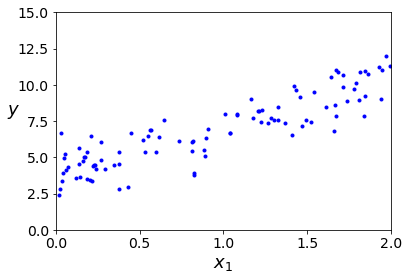

In [3]:
plt.plot(X,y,"b.")
plt.xlabel("$x_1$",fontsize=18)
plt.ylabel("$y$",rotation=0,fontsize=18)
plt.axis([0,2,0,15])
plt.show()

In [4]:
X_b=np.c_[np.ones((100,1)),X]
theta_best=np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

In [5]:
theta_best

array([[3.79159462],
       [3.2824547 ]])

In [6]:
X_new=np.array([[0],[2]])
X_new_b=np.c_[np.ones((2,1)),X_new]
y_predict=X_new_b.dot(theta_best)
y_predict

array([[ 3.79159462],
       [10.35650402]])

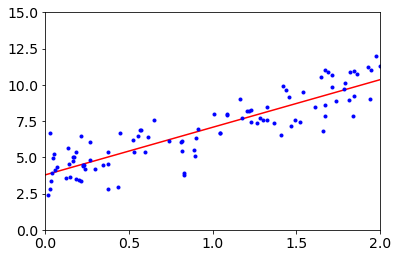

In [7]:
plt.plot(X_new,y_predict,"r-")
plt.plot(X,y,"b.")
plt.axis([0,2,0,15])
plt.show()

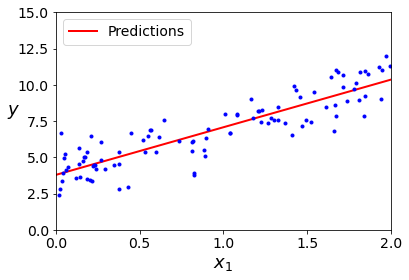

In [8]:
plt.plot(X_new,y_predict,"r-",linewidth=2,label="Predictions")
plt.plot(X,y,"b.")
plt.xlabel("$x_1$",fontsize=18)
plt.ylabel("$y$",rotation=0,fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([0, 2, 0, 15])
plt.show()

In [9]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg.fit(X,y)
lin_reg.intercept_,lin_reg.coef_

(array([3.79159462]), array([[3.2824547]]))

In [10]:
lin_reg.predict(X_new)

array([[ 3.79159462],
       [10.35650402]])

In [11]:
theta_best_svd,residuals,rank,s=np.linalg.lstsq(X_b,y,rcond=1e-6)
theta_best_svd

array([[3.79159462],
       [3.2824547 ]])

In [12]:
np.linalg.pinv(X_b).dot(y)

array([[3.79159462],
       [3.2824547 ]])

In [13]:
eta=0.1
n_iterations=1500
m=100
theta=np.random.randn(2,1)

for iteration in range(n_iterations):
    gradients=2/m*X_b.T.dot(X_b.dot(theta)-y)
    theta=theta-eta*gradients

In [14]:
theta

array([[3.79159462],
       [3.2824547 ]])

In [15]:
X_new_b.dot(theta)

array([[ 3.79159462],
       [10.35650402]])

In [16]:
theta_path_bgd=[]

def plot_gradient_descent(theta,eta,theta_path=None):
    m=len(X_b)
    plt.plot(X,y,"b.")
    n_iterations=1000
    for iteration in range(n_iterations):
        if iteration <10:
            y_predict=X_new_b.dot(theta)
            style="b-"if iteration >0 else "r--"
            plt.plot(X_new,y_predict,style)
        gradients=2/m*X_b.T.dot(X_b.dot(theta)-y)
        theta=theta-eta*gradients
        if theta_path is not None:
            theta_path.append(theta)
    plt.xlabel("$x_1$",fontsize=18)
    plt.ylabel("$y$",rotation=0,fontsize=18)
    plt.legend(loc="upper left", fontsize=14)
    plt.axis([0, 2, 0, 15])
    plt.title(r"$\eta={}$".format(eta),fontsize=16)

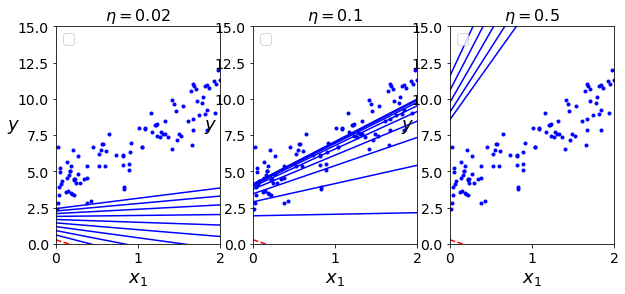

In [17]:
np.random.seed(17)
theta=np.random.randn(2,1)

plt.figure(figsize=(10,4))
plt.subplot(131);plot_gradient_descent(theta,eta=0.02)
plt.ylabel("$y$",rotation=0,fontsize=18)
plt.subplot(132),plot_gradient_descent(theta,eta=0.1,theta_path=theta_path_bgd)
plt.subplot(133),plot_gradient_descent(theta,eta=0.5)

plt.show()

In [18]:
theta_path_sgd=[]
m=len(X_b)
np.random.seed(17)

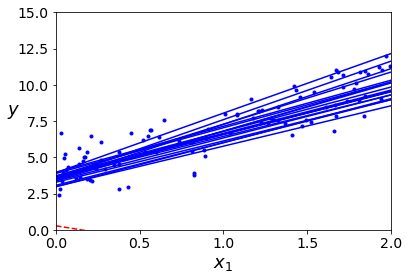

In [19]:
n_epochs=50
t0, t1=5, 50

def learning_schedule(t):
    return t0/(t+t1)

theta = np.random.randn(2,1)

for epoch in range(n_epochs):
    for i in range(m):
        if epoch == 0 and i <20:
            y_predict= X_new_b.dot(theta)
            style="b-" if i>0 else "r--"
            plt.plot(X_new,y_predict,style)
        random_index=np.random.randint(m)
        xi=X_b[random_index:random_index+1]
        yi=y[random_index:random_index+1]
        gradients=2*xi.T.dot(xi.dot(theta)-yi)
        eta=learning_schedule(epoch*m+i)
        theta=theta-eta*gradients
        theta_path_sgd.append(theta)
        
plt.plot(X,y,"b.")
plt.xlabel("$x_1$",fontsize=18)
plt.ylabel("$y$",rotation=0,fontsize=18)
plt.axis([0,2,0,15])
plt.show()

In [20]:
from sklearn.linear_model import SGDRegressor
sgd_reg=SGDRegressor(max_iter=10,tol=-np.infty,penalty=None,eta0=0.1,random_state=17)
sgd_reg.fit(X,y.ravel())

SGDRegressor(eta0=0.1, max_iter=10, penalty=None, random_state=17, tol=-inf)

In [21]:
sgd_reg.intercept_,sgd_reg.coef_

(array([3.78397538]), array([3.25590556]))

In [22]:
theta_path_mgd=[]
n_iterations= 50 
minibatch_size= 20 
np.random.seed(17)
theta=np.random.randn(2,1)

t0,t1=200,1000
def learning_schedule(t):
    return t0/(t+t1)

t=0
for epoch in range(n_iterations):
    shuffled_indices=np.random.permutation(m)
    X_b_shuffled=X_b[shuffled_indices]
    y_shuffled=y[shuffled_indices]
    for i in range(0,m,minibatch_size):
        t+=1
        ix=X_b_shuffled[i:i+minibatch_size]
        iy=y_shuffled[i:i+minibatch_size]
        gradients= 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)
        eta=learning_schedule(t)
        theta=theta-eta*gradients
        theta_path_mgd.append(theta)
        

In [23]:
theta

array([[ 5.75238516],
       [-1.09825639]])

In [24]:
theta_path_bgd = np.array(theta_path_bgd)
theta_path_sgd = np.array(theta_path_sgd)
theta_path_mgd = np.array(theta_path_mgd)

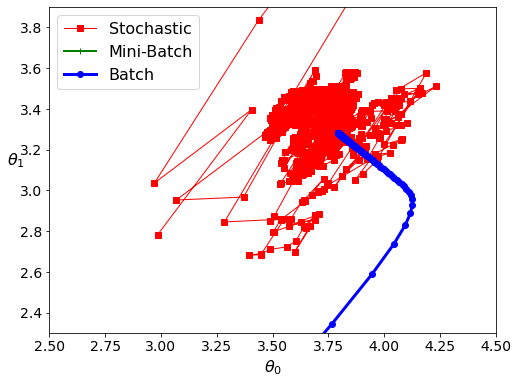

In [25]:
plt.figure(figsize=(8,6))
plt.plot(theta_path_sgd[:,0],theta_path_sgd[:,1],"r-s",linewidth=1,label="Stochastic")
plt.plot(theta_path_mgd[:,0],theta_path_mgd[:,1],"g-+",linewidth=2,label="Mini-Batch")
plt.plot(theta_path_bgd[:,0],theta_path_bgd[:,1],"b-o",linewidth=3,label="Batch")
plt.legend(loc="upper left",fontsize=16)
plt.xlabel(r"$\theta_0$",fontsize=16)
plt.ylabel(r"$\theta_1$",fontsize=16,rotation=0)
plt.axis([2.5,4.5,2.3,3.9])
plt.show()

In [26]:
import numpy as np 
import numpy.random as rnd
np.random.seed(17)

In [27]:
m=100
X=6*np.random.rand(m,1)-3
y=0.5*X**2+X+2+np.random.randn(m,1)


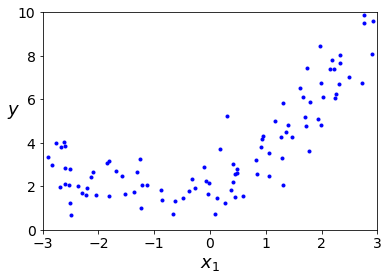

In [28]:
plt.plot(X,y,"b.")
plt.xlabel("$x_1$",fontsize=18)
plt.ylabel("$y$",rotation=0,fontsize=18)
plt.axis([-3,3,0,10])
plt.show()

In [29]:
from sklearn.preprocessing import PolynomialFeatures
poly_features=PolynomialFeatures(degree=2,include_bias=False)
X_poly=poly_features.fit_transform(X)
X[0]

array([-1.23200998])

In [30]:
X_poly[0]

array([-1.23200998,  1.5178486 ])

In [31]:
lin_reg=LinearRegression()
lin_reg.fit(X_poly,y)
lin_reg.intercept_,lin_reg.coef_

(array([2.16151499]), array([[1.06929872, 0.48313285]]))

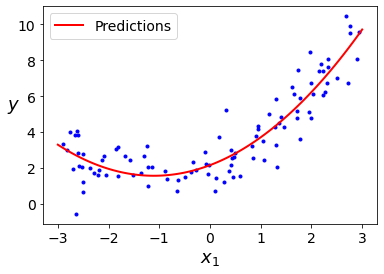

In [32]:
X_new=np.linspace(-3,3,100).reshape(100,1)
X_new_poly=poly_features.transform(X_new)
y_new=lin_reg.predict(X_new_poly)
plt.plot(X,y,"b.")
plt.plot(X_new,y_new,"r-",linewidth=2,label="Predictions")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.show()


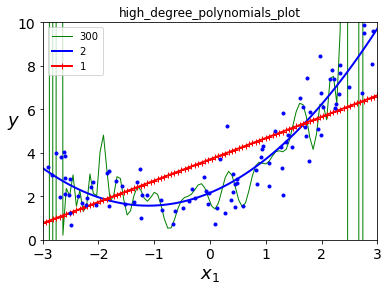

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

for style,width,degree in (("g-",1,300),("b-",2,2),("r-+",2,1)):
    polybig_features=PolynomialFeatures(degree=degree,include_bias=False)
    std_scalar=StandardScaler()
    lin_reg=LinearRegression()
    polynomial_regression=Pipeline([
        ("poly_features",polybig_features),
        ("std_scalar",std_scalar),
        ("lin_reg",lin_reg),
    ])
    polynomial_regression.fit(X,y)
    y_newbig=polynomial_regression.predict(X_new)
    plt.title('high_degree_polynomials_plot')
    plt.plot(X_new,y_newbig,style,label=str(degree),linewidth=width)
    
plt.plot (X,y,"b.",linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$",fontsize=18)
plt.ylabel("$y$",rotation=0,fontsize=18)
plt.axis([-3,3,0,10])
plt.show()


In [34]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model,X,y):
    X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2)
    train_errors,val_errors=[],[]
    for m in range(1,len(X_train)):
        model.fit(X_train[:m],y_train[:m])
        y_train_predict=model.predict(X_train[:m])
        y_val_predict=model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m],y_train_predict))
        val_errors.append(mean_squared_error(y_val,y_val_predict))
        
    plt.plot(np.sqrt(train_errors),"r-+",linewidth=2,label="train")
    plt.plot(np.sqrt(val_errors),"b-",linewidth=3,label="val")
    plt.legend(loc="upper right",fontsize=14)
    plt.xlabel("Training set size",fontsize=14)
    plt.ylabel("RMSE",fontsize=14)

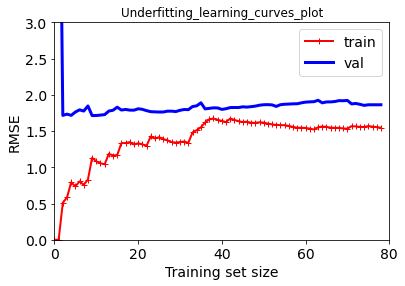

In [35]:
lin_reg=LinearRegression()
plot_learning_curves(lin_reg,X,y)
plt.axis([0,80,0,3])
plt.title("Underfitting_learning_curves_plot")
plt.show()

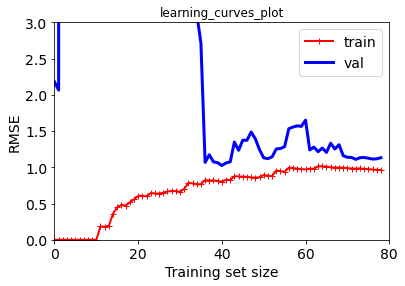

In [36]:
from sklearn.pipeline import Pipeline

polynomial_regression=Pipeline([
    ("poly_features",PolynomialFeatures(degree=10 ,include_bias=False)),
    ("lin_reg",LinearRegression()),
])
plot_learning_curves(polynomial_regression,X,y)
plt.axis([0,80,0,3])
plt.title('learning_curves_plot')
plt.show()

[[1.12362036]
 [2.85214292]
 [2.19598183]
 [1.79597545]
 [0.46805592]
 [0.46798356]
 [0.17425084]
 [2.59852844]
 [1.80334504]
 [2.12421773]
 [0.06175348]
 [2.90972956]
 [2.49732792]
 [0.63701733]
 [0.5454749 ]
 [0.55021353]
 [0.91272673]
 [1.57426929]
 [1.29583506]
 [0.87368742]]


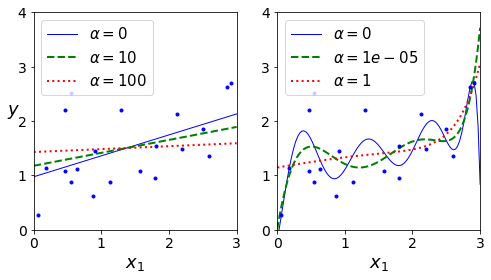

In [37]:
from sklearn.linear_model import Ridge

np.random.seed(42)
m = 20
X= 3 * np.random.rand(m,1)
y= 1 + 0.5 * X + np.random.randn(m,1) / 1.5
X_new=np.linspace(0,3,100).reshape(100,1)
print(X)
def plot_model(model_class,polynomial,alphas,**model_kargs):
    for alpha,style in zip(alphas,("b-","g--","r:")):
        model=model_class(alpha,**model_kargs)if alpha>0 else LinearRegression()
        if polynomial:
            model=Pipeline([
            ("Poly_features",PolynomialFeatures(degree=10,include_bias=False)),
            ("std_scalar",StandardScaler()),
            ("regul_reg",model),
             ])
        model.fit(X,y)
        y_new_regul=model.predict(X_new)
        lw=2 if alpha >0 else 1
        plt.plot(X_new,y_new_regul,style,linewidth=lw,label=r"$\alpha = {}$".format(alpha))
    plt.plot(X,y,"b.",linewidth=3)
    plt.legend(loc="upper left", fontsize=15)
    plt.xlabel("$x_1$",fontsize=18)
    plt.axis([0,3,0,4])
    
plt.figure(figsize=(8,4))
plt.subplot(121)
plot_model(Ridge,polynomial=False,alphas=(0,10,100),random_state=17)
plt.ylabel("$y$",rotation=0,fontsize=18)
plt.subplot(122)
plot_model(Ridge,polynomial=True,alphas=(0,10**-5,1),random_state=17)

In [38]:
from sklearn.linear_model import Ridge
ridge_reg=Ridge(alpha=1,solver="cholesky",random_state=17)
ridge_reg.fit(X,y)
ridge_reg.predict([[1.5]])

array([[1.55071465]])

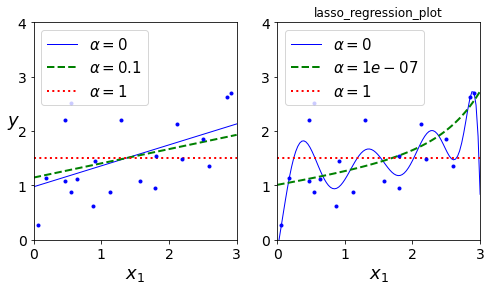

In [39]:
from sklearn.linear_model import Lasso 
plt.figure(figsize=(8,4))
plt.subplot(121)
plot_model(Lasso,polynomial=False,alphas=(0,0.1,1),random_state=17)
plt.ylabel("$y$",rotation=0,fontsize=18)
plt.subplot(122)
plot_model(Lasso,polynomial=True,alphas=(0,10**-7,1),tol=1,random_state=17)
plt.title("lasso_regression_plot")
plt.show()

In [40]:
from sklearn.linear_model import Lasso
lasso_reg=Lasso(alpha=0.1)
lasso_reg.fit(X,y)
lasso_reg.predict([[1.5]])


array([1.53788174])

In [41]:
from sklearn.linear_model import ElasticNet
Els_reg=ElasticNet(alpha=0.1,l1_ratio=0.5,random_state=17)
Els_reg.fit(X,y)
Els_reg.predict([[1.5]])

array([1.54333232])

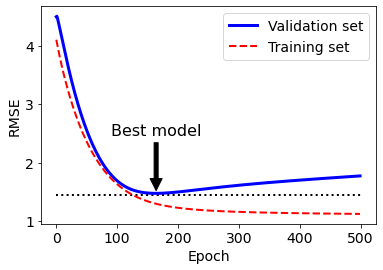

In [42]:
np.random.seed(17)
m=100
X=6*np.random.rand(m,1)-3
y=2+X+0.5*X**2+np.random.randn(m,1)

X_train,X_val,y_train,y_val=train_test_split(X[:50],y[:50].ravel(),test_size=0.5,random_state=42)

poly_scaler=Pipeline([
    ("poly_features",PolynomialFeatures(degree=90,include_bias=False)),
    ("std_scalar",StandardScaler()),
])

X_train_poly_scaled=poly_scaler.fit_transform(X_train)
X_val_poly_scaled=poly_scaler.transform(X_val)


sgd_reg= SGDRegressor(max_iter=1,tol=-np.infty,penalty=None,eta0=0.0005,
                     warm_start=True,learning_rate="constant",random_state=17)

n_epochs=500
train_errors,val_errors=[],[]
for epoch in range(n_epochs):
    sgd_reg.fit(X_train_poly_scaled,y_train)
    y_train_predict=sgd_reg.predict(X_train_poly_scaled)
    y_val_predict=sgd_reg.predict(X_val_poly_scaled)
    train_errors.append(mean_squared_error(y_train,y_train_predict))
    val_errors.append(mean_squared_error(y_val,y_val_predict))

best_epoch=np.argmin(val_errors)
best_val_rmse=np.sqrt(val_errors[best_epoch])

plt.annotate('Best model',
            xy=(best_epoch,best_val_rmse),
            xytext=(best_epoch,best_val_rmse+1),
            ha="center",
            arrowprops=dict(facecolor='black',shrink=0.05),
            fontsize=16,
            )
best_val_rmse-=0.03
plt.plot([0,n_epochs],[best_val_rmse,best_val_rmse],"k:",linewidth=2)
plt.plot(np.sqrt(val_errors),"b-",linewidth=3,label="Validation set")
plt.plot(np.sqrt(train_errors),"r--",linewidth=2,label="Training set")
plt.legend(loc="upper right",fontsize=14)
plt.xlabel("Epoch",fontsize=14)
plt.ylabel("RMSE",fontsize=14)
plt.show()

In [43]:
from sklearn.base import clone
sgd_reg=SGDRegressor(max_iter=1,tol=-np.infty,warm_start=True,learning_rate="constant"
                     ,eta0=0.0005,random_state=17)
minimum_val_error=float("inf")
best_epoch=None
best_model=None
for epoch in range(1000):
    sgd_reg.fit(X_train_poly_scaled,y_train)
    y_val_predict=sgd_reg.predict(X_val_poly_scaled)
    val_error=mean_squared_error(y_val,y_val_predict)
    if val_error < minimum_val_error :
        minimum_val_error=val_error
        best_epoch=epoch
        best_model=clone(sgd_reg)

In [44]:
best_epoch,best_model

(164,
 SGDRegressor(eta0=0.0005, learning_rate='constant', max_iter=1, random_state=17,
              tol=-inf, warm_start=True))

In [45]:
t1a, t1b, t2a, t2b = -1, 3, -1.5, 1.5

# ignoring bias term
t1s = np.linspace(t1a, t1b, 500)
t2s = np.linspace(t2a, t2b, 500)
t1, t2 = np.meshgrid(t1s, t2s)
T = np.c_[t1.ravel(), t2.ravel()]
Xr = np.array([[-1, 1], [-0.3, -1], [1, 0.1]])
yr = 2 * Xr[:, :1] + 0.5 * Xr[:, 1:]

J = (1/len(Xr) * np.sum((T.dot(Xr.T) - yr.T)**2, axis=1)).reshape(t1.shape)

N1 = np.linalg.norm(T, ord=1, axis=1).reshape(t1.shape)
N2 = np.linalg.norm(T, ord=2, axis=1).reshape(t1.shape)

t_min_idx = np.unravel_index(np.argmin(J), J.shape)
t1_min, t2_min = t1[t_min_idx], t2[t_min_idx]

t_init = np.array([[0.25], [-1]])

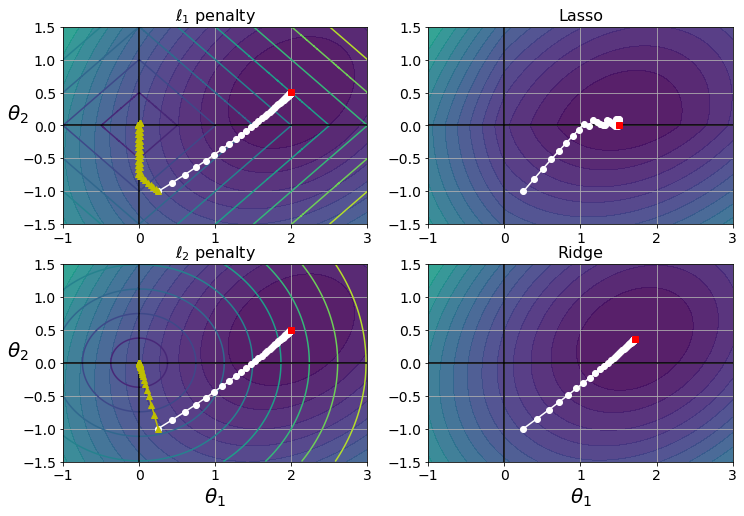

In [46]:
def bgd_path(theta, X, y, l1, l2, core = 1, eta = 0.1, n_iterations = 50):
    path = [theta]
    for iteration in range(n_iterations):
        gradients = core * 2/len(X) * X.T.dot(X.dot(theta) - y) + l1 * np.sign(theta) + 2 * l2 * theta

        theta = theta - eta * gradients
        path.append(theta)
    return np.array(path)

plt.figure(figsize=(12, 8))
for i, N, l1, l2, title in ((0, N1, 0.5, 0, "Lasso"), (1, N2, 0,  0.1, "Ridge")):
    JR = J + l1 * N1 + l2 * N2**2
    
    tr_min_idx = np.unravel_index(np.argmin(JR), JR.shape)
    t1r_min, t2r_min = t1[tr_min_idx], t2[tr_min_idx]

    levelsJ=(np.exp(np.linspace(0, 1, 20)) - 1) * (np.max(J) - np.min(J)) + np.min(J)
    levelsJR=(np.exp(np.linspace(0, 1, 20)) - 1) * (np.max(JR) - np.min(JR)) + np.min(JR)
    levelsN=np.linspace(0, np.max(N), 10)
    
    path_J = bgd_path(t_init, Xr, yr, l1=0, l2=0)
    path_JR = bgd_path(t_init, Xr, yr, l1, l2)
    path_N = bgd_path(t_init, Xr, yr, np.sign(l1)/3, np.sign(l2), core=0)

    plt.subplot(221 + i * 2)
    plt.grid(True)
    plt.axhline(y=0, color='k')
    plt.axvline(x=0, color='k')
    plt.contourf(t1, t2, J, levels=levelsJ, alpha=0.9)
    plt.contour(t1, t2, N, levels=levelsN)
    plt.plot(path_J[:, 0], path_J[:, 1], "w-o")
    plt.plot(path_N[:, 0], path_N[:, 1], "y-^")
    plt.plot(t1_min, t2_min, "rs")
    plt.title(r"$\ell_{}$ penalty".format(i + 1), fontsize=16)
    plt.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        plt.xlabel(r"$\theta_1$", fontsize=20)
    plt.ylabel(r"$\theta_2$", fontsize=20, rotation=0)

    plt.subplot(222 + i * 2)
    plt.grid(True)
    plt.axhline(y=0, color='k')
    plt.axvline(x=0, color='k')
    plt.contourf(t1, t2, JR, levels=levelsJR, alpha=0.9)
    plt.plot(path_JR[:, 0], path_JR[:, 1], "w-o")
    plt.plot(t1r_min, t2r_min, "rs")
    plt.title(title, fontsize=16)
    plt.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        plt.xlabel(r"$\theta_1$", fontsize=20)

plt.show()
             

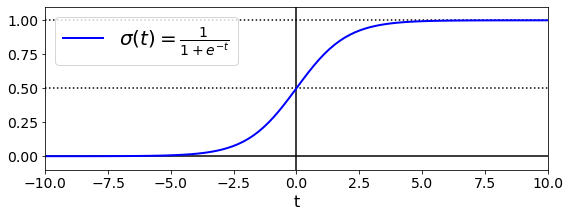

In [47]:
t=np.linspace(-10,10,100)
sig=1/(1+np.exp(-t))
plt.figure(figsize=(9,3))
plt.plot([-10,10],[0,0],"k-")
plt.plot([-10,10],[0.5,0.5],"k:")
plt.plot([-10,10],[1,1],"k:")
plt.plot([0,0],[-1.1,1.1],"k-")
plt.plot(t,sig,"b-",linewidth=2,label=r"$\sigma(t)=\frac{1}{1+e^{-t}}$")
plt.xlabel("t")
plt.legend(loc="upper left",fontsize=20)
plt.axis([-10,10,-0.1,1.1])
plt.show()

In [48]:
iris=pd.read_csv("../input/iris/Iris.csv")
print(iris)

      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-setosa  
..              ...  
145  

In [49]:

iris=iris.to_numpy()

In [50]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
X = iris[:, 3:5]
print(X)
y = iris[:,5] 
z=le.fit_transform(y)
l = (z == 2).astype(np.int)
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(solver="liblinear", random_state=42)
log_reg.fit(X, l)

[[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [1.7 0.4]
 [1.4 0.3]
 [1.5 0.2]
 [1.4 0.2]
 [1.5 0.1]
 [1.5 0.2]
 [1.6 0.2]
 [1.4 0.1]
 [1.1 0.1]
 [1.2 0.2]
 [1.5 0.4]
 [1.3 0.4]
 [1.4 0.3]
 [1.7 0.3]
 [1.5 0.3]
 [1.7 0.2]
 [1.5 0.4]
 [1.0 0.2]
 [1.7 0.5]
 [1.9 0.2]
 [1.6 0.2]
 [1.6 0.4]
 [1.5 0.2]
 [1.4 0.2]
 [1.6 0.2]
 [1.6 0.2]
 [1.5 0.4]
 [1.5 0.1]
 [1.4 0.2]
 [1.5 0.1]
 [1.2 0.2]
 [1.3 0.2]
 [1.5 0.1]
 [1.3 0.2]
 [1.5 0.2]
 [1.3 0.3]
 [1.3 0.3]
 [1.3 0.2]
 [1.6 0.6]
 [1.9 0.4]
 [1.4 0.3]
 [1.6 0.2]
 [1.4 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [4.7 1.4]
 [4.5 1.5]
 [4.9 1.5]
 [4.0 1.3]
 [4.6 1.5]
 [4.5 1.3]
 [4.7 1.6]
 [3.3 1.0]
 [4.6 1.3]
 [3.9 1.4]
 [3.5 1.0]
 [4.2 1.5]
 [4.0 1.0]
 [4.7 1.4]
 [3.6 1.3]
 [4.4 1.4]
 [4.5 1.5]
 [4.1 1.0]
 [4.5 1.5]
 [3.9 1.1]
 [4.8 1.8]
 [4.0 1.3]
 [4.9 1.5]
 [4.7 1.2]
 [4.3 1.3]
 [4.4 1.4]
 [4.8 1.4]
 [5.0 1.7]
 [4.5 1.5]
 [3.5 1.0]
 [3.8 1.1]
 [3.7 1.0]
 [3.9 1.2]
 [5.1 1.6]
 [4.5 1.5]
 [4.5 1.6]
 [4.7 1.5]
 [4.4 1.3]
 [4.1 1.3]
 [4.0 1.3]
 [4.4 1.2]

LogisticRegression(random_state=42, solver='liblinear')

In [51]:
X_new=np.linspace(0,3,1000).reshape(-1,1)
y_proba=log_reg.predict_proba(X_new)

plt.plot(X_new,y_proba[:,1],"g-",linewidth=2,label="Iris-Virginica")
plt.plot(X_new,y_proba[:,0],"b--",linewidth=2,label=" Not Iris-Virginica")

ValueError: X has 1 features per sample; expecting 2

In [52]:
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0]
decision_boundary

NameError: name 'y_proba' is not defined

In [53]:
log_reg.predict([[1.7],[1.5]])

ValueError: X has 1 features per sample; expecting 2

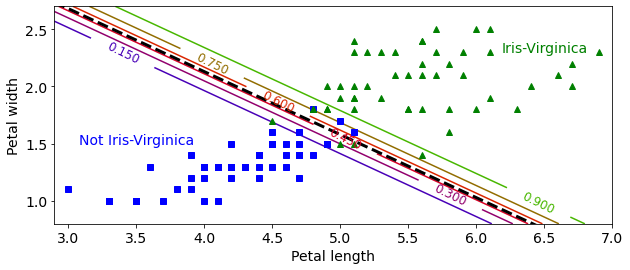

In [54]:
from sklearn.linear_model import LogisticRegression
X = iris[:, (3,4)]

log_reg=LogisticRegression(solver="liblinear",C=10**10,random_state=42)
log_reg.fit(X,l)

x0,x1=np.meshgrid(
      np.linspace(2.9,7,500).reshape(-1,1),
      np.linspace(0.8,2.7,200).reshape(-1,1),
      )

X_new=np.c_[x0.ravel(),x1.ravel()]

y_proba=log_reg.predict_proba(X_new)

plt.figure(figsize=(10,4))
plt.plot(X[l==0,0],X[l==0,1],"bs")
plt.plot(X[l==1,0],X[l==1,1],"g^")

zz = y_proba[:, 1].reshape(x0.shape)
contour = plt.contour(x0, x1, zz, cmap=plt.cm.brg)

left_right = np.array([2.9, 7])
boundary = -(log_reg.coef_[0][0] * left_right + log_reg.intercept_[0]) / log_reg.coef_[0][1]


plt.clabel(contour, inline=1, fontsize=12)
plt.plot(left_right, boundary, "k--", linewidth=3)
plt.text(3.5, 1.5, "Not Iris-Virginica", fontsize=14, color="b", ha="center")
plt.text(6.5, 2.3, "Iris-Virginica", fontsize=14, color="g", ha="center")
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.axis([2.9, 7, 0.8, 2.7])
plt.show()

In [55]:
X = iris[:, (3,4)]
softmax_reg=LogisticRegression(multi_class="multinomial",solver="lbfgs",C=10,random_state=42)
softmax_reg.fit(X,z)

LogisticRegression(C=10, multi_class='multinomial', random_state=42)

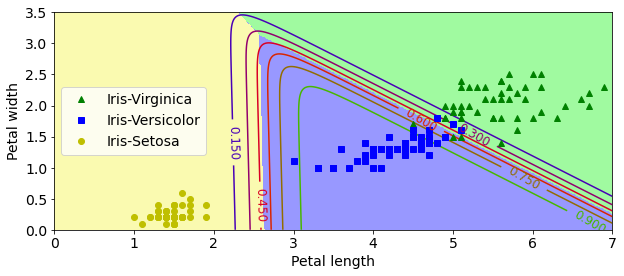

In [56]:
x0,x1=np.meshgrid(
      np.linspace(0,8,500).reshape(-1,1),
      np.linspace(0,3.5,200).reshape(-1,1),
)
X_new=np.c_[x0.ravel(),x1.ravel()]

y_proba=softmax_reg.predict_proba(X_new)
y_predict=softmax_reg.predict(X_new)

zz1=y_proba[:,1].reshape(x0.shape)
zz=y_predict.reshape(x0.shape)

plt.figure(figsize=(10,4))
plt.plot(X[z==2, 0], X[z==2, 1], "g^", label="Iris-Virginica")
plt.plot(X[z==1, 0], X[z==1, 1], "bs", label="Iris-Versicolor")
plt.plot(X[z==0, 0], X[z==0, 1], "yo", label="Iris-Setosa")

from matplotlib.colors import ListedColormap
from matplotlib.colors import ListedColormap
custom_cmap=ListedColormap(['#fafab0',"#9898ff","#a0faa0"])

plt.contourf(x0,x1,zz, cmap=custom_cmap)
contour=plt.contour(x0,x1,zz1,cmap=plt.cm.brg)
plt.clabel(contour, inline=1, fontsize=12)
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="center left",fontsize=14)
plt.axis([0, 7, 0, 3.5])
plt.show()

In [57]:
softmax_reg.predict([[5, 2]])

array([2])

In [58]:
softmax_reg.predict_proba([[5, 2]])

array([[6.33134078e-07, 5.75276067e-02, 9.42471760e-01]])